## Importing the libraries

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import json

## Importing the dataset

In [9]:
df = pd.read_csv("../../dataSet/marketing_and_sales_clean.csv")

## Splitting the dataset into the Training set and Test set

In [10]:
X = df[["TV", "Radio", "Influencer", "Social Media"]].values
y = df[["Sales"]].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 0)

On entraine le model sur 2/3 des données, le 3e servira au test

## Training

In [11]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

Modele de regression linéaire très simple sans tuning

In [12]:
print('Coefficients: \n', lm.coef_)

Coefficients: 
 [[ 3.56156394  0.00491522  0.02579065 -0.02707963]]


## Prédiction

Text(0, 0.5, 'Predicted Y')

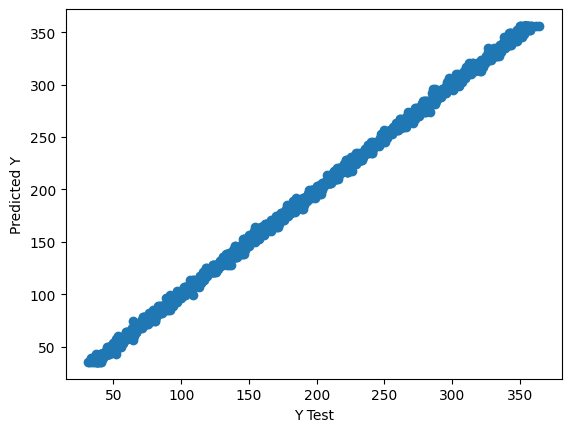

In [13]:
predictions = lm.predict(X_test)
plt.scatter(y_test,predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

## Regression Evaluation Metrics

In [ ]:
MAE = metrics.mean_absolute_error(y_test, predictions)
MSE = metrics.mean_squared_error(y_test, predictions)
RMSE = metrics.root_mean_squared_error(y_test, predictions)
R2 = metrics.r2_score(y_test, predictions)
print(f"MAE : {MAE}\nMSE : {MSE}\nRMSE : {RMSE}\nR2 : {R2}\n")
with open('../saved_models/linear_regression/metrics.json', 'w') as f:
    f.write(json.dump({MAE, MSE, RMSE, R2}))

MAE : 2.3800226481375217
MSE : 8.923670826446058
RMSE : 2.9872513832026355
R2 : 0.9989850307971435



## Export model

In [15]:
import pickle

# save
with open('../saved_models/linear_regression/model.pkl','wb') as f:
    pickle.dump(lm,f)